<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/4_model_training/4_0_model_training_plan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4_0_model_training_plan


## Introducción y Resumen

El objetivo de esta notebook es generar las ventanas de entrada (X) y targets (y) para los horizontes de 30, 60 y 90 minutos, aplica el escalado de features sobre cada conjunto (train, valid, test) y finalmente guarda las ventanas escaladas en disco, dejándolas listas para el entrenamiento de modelos.

0. Configuración del Entorno

    Se conecta Google Drive y se clona el repositorio de trabajo. Se instalan e importan librerías necesarias como pandas, numpy, matplotlib y seaborn. Se cargan los datasets procesados previamente y se muestra un resumen de la información de los datasets.

1. Carga de datos

    Se importan los datasets procesados `mnq_train`, `mnq_valid` y `mnq_test`. Se revisa su estructura (filas, columnas, tipos de datos) y también de importa el listado de features seleccionados para cada ventana de tiempo.





## 0. Configuración del Entorno


### 0.1. Clonado de repositorio / Acceso a Drive

In [1]:
#Clonamos el repo
#LINK DE REPOSITORIO: https://github.com/GUNAPILLCO/neural_profit
#!git clone https://github.com/GUNAPILLCO/neural_profit.git

In [2]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/neural_profit"

Mounted at /content/drive


### 0.2. Instalación de librerías


In [3]:
#!{sys.executable} -m pip install -q ta
#print("Librería instalada: technical-analysis")

### 0.3. Importación de librerías


In [4]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
#import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib

## 1. Carga de datos

### 1.1. Carga de datasets `mnq_train`, `mnq_valid` y `mnq_test`






In [5]:
def load_data(data: str):

    data_path = f'{drive_path}/3_dataset_preparation/mnq_{data}.parquet'
    # Leer el archivo Parquet y cargarlo en un DataFrame
    df = pd.read_parquet(data_path)

    # Asegurar que el índice esté en formato datetime
    df.index = pd.to_datetime(df.index)

    # Crear una nueva columna 'date' con la fecha extraída del índice
    df['date'] = df.index.date

    # Reordenar columnas: 'date', 'time_str', y luego el resto
    cols = ['date'] + [col for col in df.columns if col not in ['date']]

    df = df[cols]

    return df

In [6]:
#mnq_train = load_data("train")
#mnq_valid = load_data("valid")
#mnq_test = load_data("test")

### 1.2. Información de datasets


In [7]:
def info_dataset(df, name: str):
  print(f"Información del dataset {name}:\n")

  # Contar valores únicos en la columna 'date'
  num_dias = df['date'].nunique()
  print(f"\tCantidad de días: {num_dias}")

  # Filtrar valores válidos
  validos_por_dia = df.dropna(subset=['close']).groupby('date').size()

  # Calcular el promedio
  promedio_por_fecha = validos_por_dia.mean()
  print(f"\tRegistros por día: {int(promedio_por_fecha)}")

  primer_hora = df.index[0].strftime('%H:%M')
  ultima_hora = df.index[-1].strftime('%H:%M')
  zona_horaria = df.index[0].tzinfo


  print(f"\tHora diaria de inicio {primer_hora}")
  print(f"\tHora diaria de final {ultima_hora}")
  print(f"\tZona horaria: {zona_horaria}\n")

  return num_dias, promedio_por_fecha

In [8]:
#info_dataset(mnq_train, 'mnq_train')
#info_dataset(mnq_valid, 'mnq_valid')
#info_dataset(mnq_test, 'mnq_test')

### 1.3. Carga de listado de features por ventana de tiempo

In [9]:
import json

# Ruta al archivo guardado
path = f'{drive_path}/2_feature_engineering/features_list.json'

#with open(path, "r") as f:
#    features_dict = json.load(f)

# Extraer las listas
#features_to_30 = features_dict["features_to_30"]
#features_to_60 = features_dict["features_to_60"]
#features_to_90 = features_dict["features_to_90"]


In [10]:
#print(f'Listado de features para 30min: {features_to_30}')
#print(f'Listado de features para 60min: {features_to_60}')
#print(f'Listado de features para 90min: {features_to_90}')

## 2. Carga de ventanas `X_train_*_scaled`, `X_valid_*_scaled`, `X_test_*_scaled`

### 2.0. Funciones

#### Función para cargar ventanas

In [11]:
def load_windows_and_scaler(target: str, scaled=True):
    """
    Carga datasets (X, y) para train, valid y test junto con el scaler global.

    Parámetros
    ----------
    drive_path : str
        Ruta base donde se encuentran los archivos.
    scaled : bool, default=True
        Si True busca en la carpeta 'ventanas_x_y_scaled',
        si False en 'ventanas_x_y'.

    Retorna
    -------
    X_train, y_train, X_valid, y_valid, X_test, y_test, scaler
    """

    #Ruta de ventandas escaladas
    path_train  = f'{drive_path}/3_dataset_preparation/xy_windows_scaled/xy_train_{target}_scaled.npz'
    path_valid  = f'{drive_path}/3_dataset_preparation/xy_windows_scaled/xy_valid_{target}_scaled.npz'
    path_test   = f'{drive_path}/3_dataset_preparation/xy_windows_scaled/xy_test_{target}_scaled.npz'

    #Ruta de escalador
    path_scaler = f"{drive_path}/3_dataset_preparation/global_scaler_{target}.pkl"

    # Cargar npz
    data_train = np.load(path_train)
    data_valid = np.load(path_valid)
    data_test  = np.load(path_test)

    # Extraer X, y
    X_train, y_train = data_train["X"], data_train["y"]
    X_valid, y_valid = data_valid["X"], data_valid["y"]
    X_test,  y_test  = data_test["X"],  data_test["y"]

    # Cargar scaler
    scaler = joblib.load(path_scaler)

    return X_train, y_train, X_valid, y_valid, X_test, y_test, scaler


#### Función para revisar información de ventanas

In [12]:
def xy_info(target: str, X_train, y_train, X_valid, y_valid, X_test, y_test):
    print(f'Información para horizonte de {target} minutos:')

    for name, X, y in [
        ("entrenamiento", X_train, y_train),
        ("validación", X_valid, y_valid),
        ("testeo", X_test, y_test),
    ]:
        print(f'\nSet de {name}:')
        print(f'\t{X.shape[0]} ventanas (n_samples).')

        if X.ndim == 2:

            print(f'\t{X.shape[1]} features totales por ventana (aplanado). Dimensión 2D: (n_samples, window_size * len(features_{target})')
        elif X.ndim == 3:

            print(f'\t{X.shape[1]} pasos en lookback × {X.shape[2]} features por paso. Dimensión 3D: (n_samples, window_size, len(features_{target})')

        print(f'\t{y.shape[0]} targets.')
        print(f'\tDistribución y: mean={y.mean():.6f}, std={y.std():.6f}, min={y.min():.6f}, max={y.max():.6f}')

### 2.1 Carga de ventanas 30 minutos

In [13]:
#X_train_30_scaled, y_train_30, X_valid_30_scaled, y_valid_30, X_test_30_scaled, y_test_30, scaler_30 = load_windows_and_scaler(target = '30')

In [14]:
#xy_info( '30', X_train_30_scaled, y_train_30, X_valid_30_scaled, y_valid_30, X_test_30_scaled, y_test_30)

### 2.2 Carga de ventanas 60 minutos

In [15]:
#X_train_60_scaled, y_train_60, X_valid_60_scaled, y_valid_60, X_test_60_scaled, y_test_60, scaler_60 = load_windows_and_scaler(target = '60')

In [16]:
#xy_info( '60', X_train_60_scaled, y_train_60, X_valid_60_scaled, y_valid_60, X_test_60_scaled, y_test_60)

### 2.3 Carga de ventanas 90 minutos

In [17]:
#X_train_90_scaled, y_train_90, X_valid_90_scaled, y_valid_90, X_test_90_scaled, y_test_90, scaler_90 = load_windows_and_scaler(target = '90')

In [18]:
#xy_info('90', X_train_90_scaled, y_train_90, X_valid_90_scaled, y_valid_90, X_test_90_scaled, y_test_90)

## 3. Carga de métricas


In [19]:
def load_metrics(data: str):
    data_path = f'{drive_path}/4_model_training/{data}.parquet'
    # Leer el archivo Parquet y cargarlo en un DataFrame
    df = pd.read_parquet(data_path)
    return df

def metrics_verify(data: str) -> bool:
    data_path = f"{drive_path}/4_model_training/{data}.parquet"
    return os.path.exists(data_path)

def load_or_create_metrics (data:str):
  if metrics_verify(data):
      print(f"Las métricas existen y son almacenadas en {data[4:len(data)]}")
      model_metrics = load_metrics(data)
      #print(random_forest_metrics)
      metrics = True
  else:
      print(f"Las métricas no existen. Se crea el dataset {data[4:len(data)]} para almacenar las métricas")
      #Creamos la tabla para almacenar las métricas
      model_metrics = pd.DataFrame(columns=["RMSE", "MAE", "R2", "SMAPE", "DirAcc"])
      metrics = False

  return model_metrics, metrics


In [20]:
rf_metrics, metrics   =  load_or_create_metrics("4_1_random_forest_metrics")
xgb_metrics, metrics  =  load_or_create_metrics("4_2_xgboost_metrics")
lgbm_metrics, metrics =  load_or_create_metrics("4_3_lgbm_metrics")
cat_metrics, metrics  =  load_or_create_metrics("4_4_catboost_metrics")
mlp_metrics, metrics  =  load_or_create_metrics("4_5_mlp_metrics")
tcn_metrics, metrics =  load_or_create_metrics("4_6_tcn_metrics")
transformers_metrics, metrics  =  load_or_create_metrics("4_7_transformers_metrics")
#tabnet_metrics        =  load_or_create_metrics("4_8_tabnet_metrics")
lstm_metrics          =  load_or_create_metrics("4_8_lstm_metrics")
gru_metrics           =  load_or_create_metrics("4_9_gru_metrics")
tft_metrics           =  load_or_create_metrics("4_10_tft_metrics")


Las métricas existen y son almacenadas en random_forest_metrics
Las métricas existen y son almacenadas en xgboost_metrics
Las métricas existen y son almacenadas en lgbm_metrics
Las métricas existen y son almacenadas en catboost_metrics
Las métricas existen y son almacenadas en mlp_metrics
Las métricas existen y son almacenadas en tcn_metrics
Las métricas existen y son almacenadas en transformers_metrics
Las métricas existen y son almacenadas en lstm_metrics
Las métricas existen y son almacenadas en gru_metrics
Las métricas existen y son almacenadas en _tft_metrics


In [21]:
transformers_metrics  #pandas.core.frame.DataFrame

,RMSE,MAE,R2,SMAPE,DirAcc
transformer_30_100%,0.002053,0.001415,0.452970,111.805275,0.720148
transformer_60_100%,0.002073,0.001432,0.712301,86.124934,0.810990
transformer_90_100%,0.002221,0.001489,0.783293,77.708278,0.841964


In [29]:
lstm_metrics = lstm_metrics[0] #tuple
gru_metrics = gru_metrics[0] #tuple


KeyError: 0

In [30]:
tft_metrics = tft_metrics[0] #tuple

In [31]:
# Combinar verticalmente
model_metrics = pd.concat([rf_metrics, xgb_metrics, lgbm_metrics, cat_metrics, mlp_metrics, tcn_metrics, transformers_metrics, lstm_metrics, gru_metrics, tft_metrics], axis=0)


In [32]:
model_metrics

,RMSE,MAE,R2,SMAPE,DirAcc
RF_30_subsampleado_30%,0.002768,0.001628,0.237195,120.874522,0.698236
RF_30_subsampleado_50%,0.002782,0.001640,0.233573,121.386628,0.696868
RF_60_subsampleado_30%,0.003737,0.002029,0.326394,105.691331,0.760706
RF_60_subsampleado_50%,0.003946,0.002072,0.300929,105.248839,0.763990
RF_90_subsampleado_30%,0.004722,0.002363,0.352733,96.445722,0.794066
...,...,...,...,...,...
TFT_30_subsampleado_10%_2,0.002985,0.002532,-0.304982,131.029831,0.625477
TFT_60_subsampleado_10%_1,0.003997,0.003385,-0.237267,132.961823,0.654819
TFT_60_subsampleado_10%_2,0.005539,0.004507,-1.376273,149.686584,0.444418
TFT_90_subsampleado_10%_1,0.002139,0.002110,0.752847,113.214897,0.712309


In [54]:
#Renombro los siguientes modelos para procesarlos:
model_metrics = model_metrics.rename(index={
    "transformer_30_100%": "tran_30_100%",
    "transformer_60_100%": "tran_60_100%",
    "transformer_90_100%": "tran_90_100%"
})

In [55]:
#Creo una lista con todos los modelos.
model_list = model_metrics.index.tolist()

## 4. Comparación de modelos por horizonte

In [ ]:
#Creo una lista de modelos para cada horizonte de tiempo
models_30 = [m for m in model_list if m.split("_")[1] == "30"]
models_60 = [m for m in model_list if m.split("_")[1] == "60"]
models_90 = [m for m in model_list if m.split("_")[1] == "90"]

In [ ]:
#Filtro el dataset de métricas para quedarme solo con las métricas del horizonte
models_30 = model_metrics.loc[models_30]
models_60 = model_metrics.loc[models_60]
models_90 = model_metrics.loc[models_90]

El cálculo de `rank_avg` resume la posición de cada modelo considerando cinco métricas simultáneamente: RMSE, MAE, SMAPE, R² y DirAcc. Para las tres primeras, un menor valor indica mejor desempeño; para R² y DirAcc, un mayor valor es preferible. Esto permite obtener una medida global y comparativa del rendimiento de cada arquitectura en cada horizonte.

In [95]:
# Función para generar ranking por métrica
def ranking(df, horizon_label):
    #print(f"\nHORIZONTE {horizon_label} MIN ")

    # Orden por cada métrica
    #print("\n\tTop RMSE (menor es mejor)")
    #display(df.sort_values("RMSE").head(5))

    #print("\n\tTop MAE (menor es mejor)")
    #display(df.sort_values("MAE").head(5))

    #print("\n\tTop SMAPE (menor es mejor)")
    #display(df.sort_values("SMAPE").head(5))

    #print("\n\tTop R2 (mayor es mejor)")
    #display(df.sort_values("R2", ascending=False).head(5))

    #print("\n\tTop DirAcc (mayor es mejor)")
    #display(df.sort_values("DirAcc", ascending=False).head(5))

    # Ranking combinado
    rank_df = pd.DataFrame({
        "RMSE_rank": df["RMSE"].rank(),
        "MAE_rank": df["MAE"].rank(),
        "SMAPE_rank": df["SMAPE"].rank(),
        "R2_rank": df["R2"].rank(ascending=False),
        "DirAcc_rank": df["DirAcc"].rank(ascending=False)
    })

    df["rank_avg"] = rank_df.mean(axis=1)

    #print("\n\tRanking ")
    display(df.sort_values("rank_avg").head(10))

    return df

In [96]:
# --- 3. Gráficos recomendados ---
def plot_metric(df, metric, title):
    df_sorted = df.sort_values(metric)

    plt.figure(figsize=(10, 6))
    plt.barh(df_sorted.index, df_sorted[metric])
    plt.title(title)
    plt.xlabel(metric)
    plt.tight_layout()
    plt.show()

### 1. Horizonte 30min

In [116]:
rank_30 = ranking(models_30, 30)

,RMSE,MAE,R2,SMAPE,DirAcc,rank_avg
tran_30_100%,0.002053,0.001415,0.452970,111.805275,0.720148,1.0
XGB_30_subsampleado_50%,0.002702,0.001599,0.292092,114.573267,0.712746,4.6
CAT_30_100%,0.002775,0.001599,0.280774,114.050754,0.713378,5.0
LGBM_30_subsampleado_50%,0.002726,0.001601,0.287471,114.231020,0.711495,5.4
CAT_30_subsampleado_50%,0.002641,0.001601,0.291650,114.807198,0.710100,6.2
MLP_30_subsampleado_50%,0.002543,0.001607,0.397152,119.067749,0.699514,6.4
XGB_30_100%,0.002774,0.001606,0.281533,114.170563,0.711309,6.4
LGBM_30_subsampleado_30%,0.002875,0.001621,0.268676,114.153659,0.709463,8.2
MLP_30_subsampleado_30%,0.002537,0.001655,0.333589,120.453559,0.671852,8.4
XGB_30_subsampleado_30%,0.002928,0.001628,0.278324,114.270053,0.712751,8.4


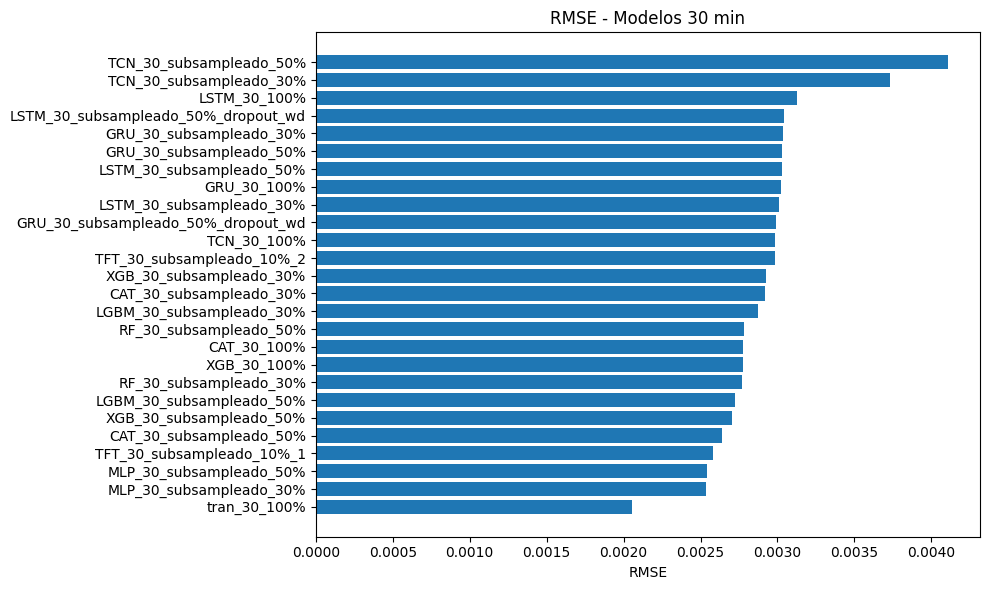

In [109]:
plot_metric(models_30, "RMSE", "RMSE - Modelos 30 min")

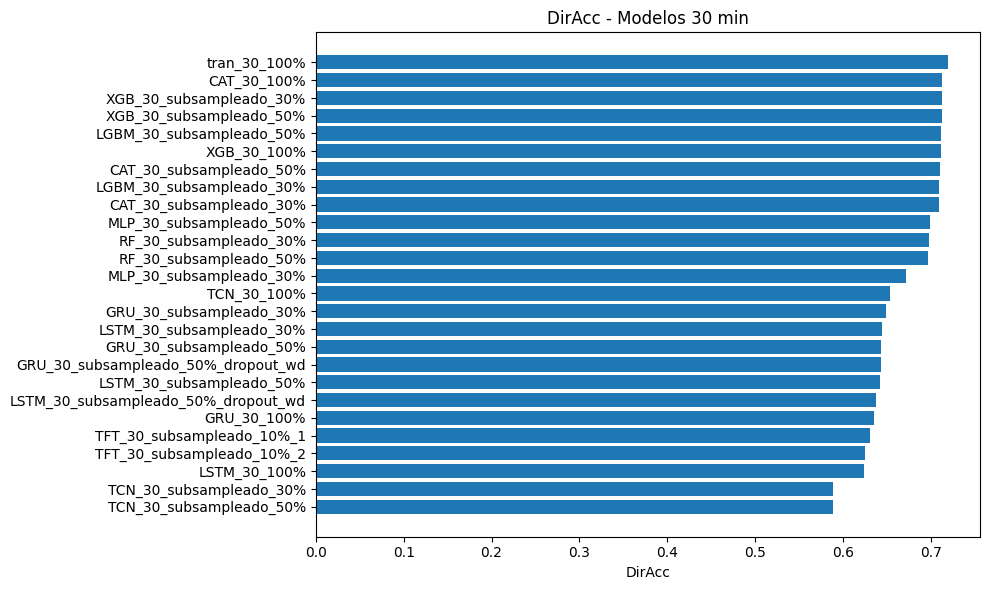

In [100]:
plot_metric(models_30, "DirAcc", "DirAcc - Modelos 30 min")

El modelo `tran_30_100%` obtiene el mejor desempeño global, con el menor `rank_avg`. Supera ampliamente al resto de modelos en error, estabilidad y precisión direccional. Detrás se ubican modelos basados en árboles como XGB, CAT y LGBM, mientras que las redes neuronales tradicionales presentan resultados más modestos.

### 2. Horizonte 60min

In [118]:
rank_60 = ranking(models_60, 60)

,RMSE,MAE,R2,SMAPE,DirAcc,rank_avg
tran_60_100%,0.002073,0.001432,0.712301,86.124934,0.810990,1.0
CAT_60_subsampleado_30%,0.003507,0.001895,0.413397,94.783952,0.789014,4.0
CAT_60_subsampleado_50%,0.003509,0.001876,0.406737,95.195925,0.786220,5.4
CAT_60_100%,0.003576,0.001891,0.406758,95.194200,0.786249,5.4
XGB_60_100%,0.003547,0.001919,0.416467,95.899622,0.786994,5.8
XGB_60_subsampleado_50%,0.003686,0.001936,0.407545,95.167915,0.790887,5.8
LGBM_60_subsampleado_30%,0.003493,0.001892,0.395036,95.774103,0.781957,6.6
MLP_60_subsampleado_30%,0.003266,0.001943,0.505579,101.422228,0.767442,6.8
MLP_60_subsampleado_50%,0.003372,0.001955,0.453291,101.994321,0.767887,7.4
LGBM_60_subsampleado_50%,0.003598,0.001905,0.405742,96.080063,0.785594,7.8


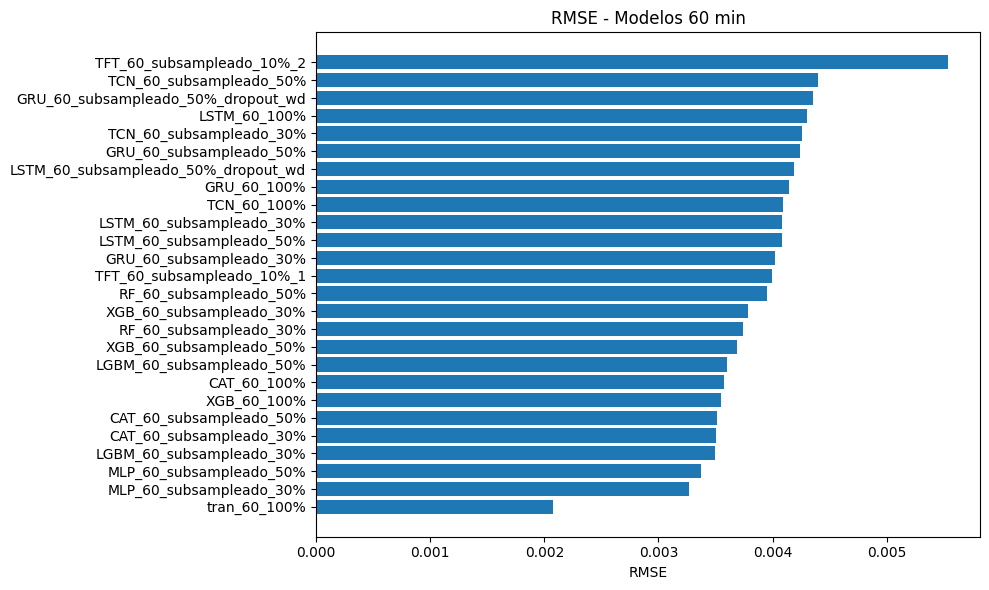

In [101]:
plot_metric(models_60, "RMSE", "RMSE - Modelos 60 min")

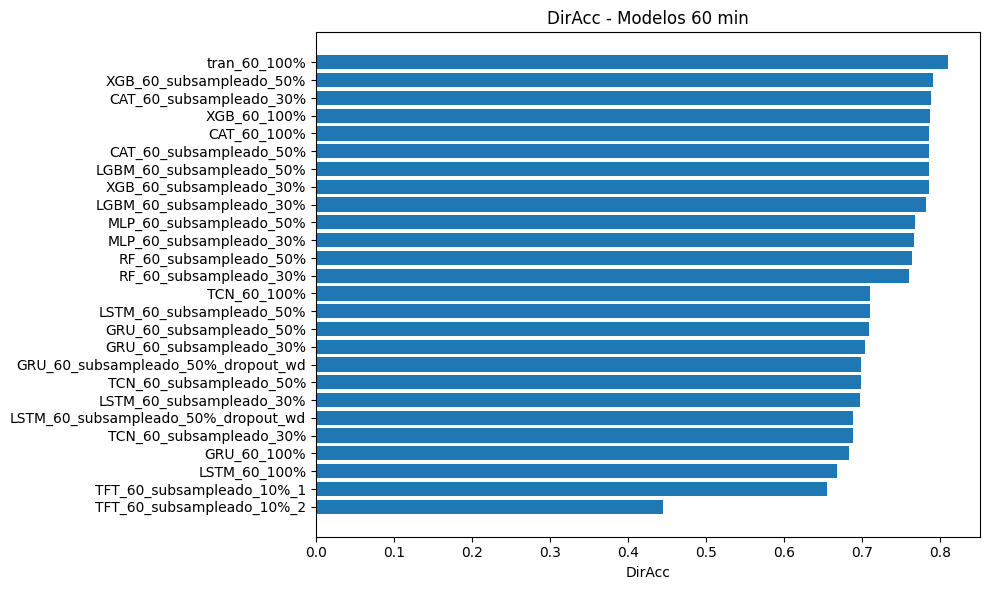

In [102]:
plot_metric(models_60, "DirAcc", "DirAcc - Modelos 60 min")

El modelo `tran_60_100%` vuelve a ocupar el primer lugar, con ventaja significativa sobre el resto. Lo siguen los modelos CAT y XGB en distintas variantes de subsampleo. La superioridad del Transformer en este horizonte es más marcada, particularmente en R² y DirAcc.

### 3. Horizonte 90min

In [117]:
rank_90 = ranking(models_90, 90)

,RMSE,MAE,R2,SMAPE,DirAcc,rank_avg
tran_90_100%,0.002221,0.001489,0.783293,77.708278,0.841964,1.2
CAT_90_100%,0.004334,0.002135,0.458094,86.951187,0.816633,4.2
CAT_90_subsampleado_50%,0.004366,0.002137,0.453938,86.784671,0.817351,5.4
XGB_90_100%,0.004334,0.002167,0.457986,87.189119,0.818053,5.6
CAT_90_subsampleado_30%,0.004337,0.002156,0.457987,87.852341,0.813713,6.8
LGBM_90_subsampleado_50%,0.004452,0.002165,0.448462,87.058502,0.817688,7.2
MLP_90_subsampleado_30%,0.003607,0.002267,0.619033,93.339665,0.794707,7.8
XGB_90_subsampleado_30%,0.004381,0.002221,0.458035,88.668659,0.814755,8.2
MLP_90_subsampleado_50%,0.004250,0.002273,0.460338,93.932838,0.803060,8.4
LGBM_90_subsampleado_30%,0.004383,0.002170,0.450930,87.363224,0.812991,8.6


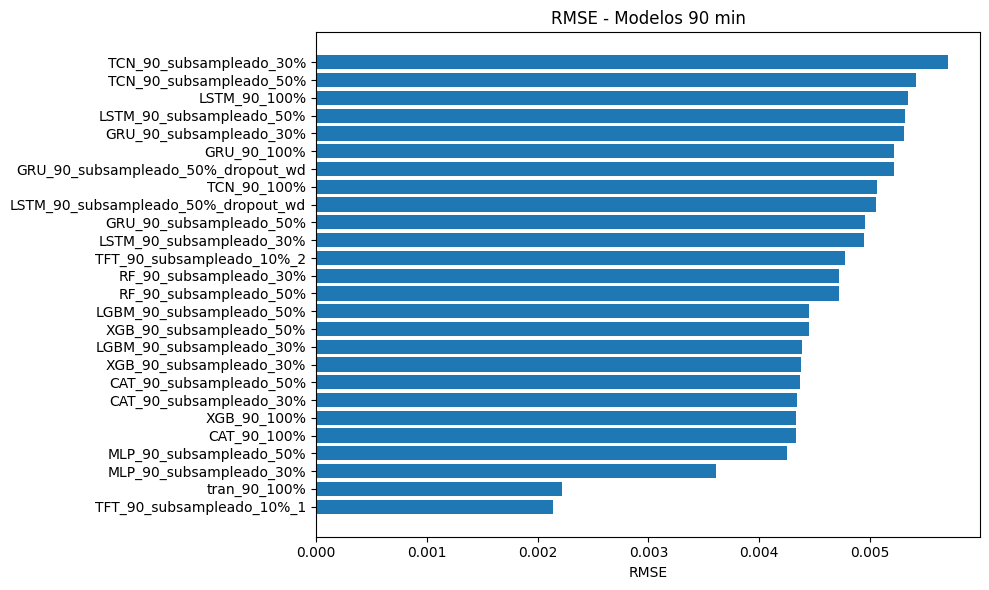

In [103]:
plot_metric(models_90, "RMSE", "RMSE - Modelos 90 min")

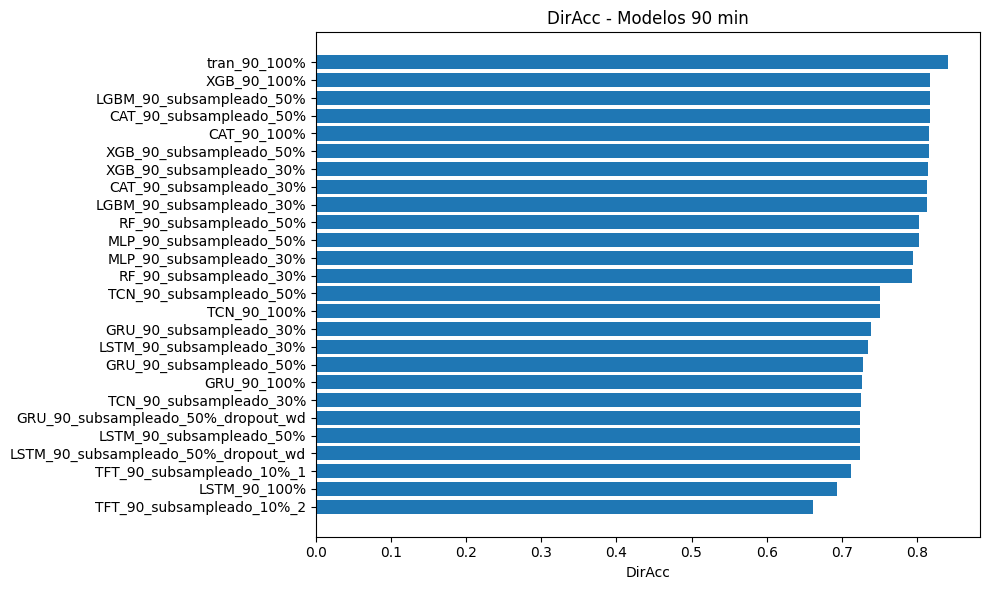

In [104]:
plot_metric(models_90, "DirAcc", "DirAcc - Modelos 90 min")

El modelo `tran_90_100%` logra nuevamente el mejor `rank_avg`. En segundo lugar aparecen `CAT` y `XGB` en sus versiones completas. En este horizonte, el Transformer muestra un aumento notable en R² y DirAcc, lo que sugiere una mayor capacidad para capturar patrones de más largo plazo.

### 4. Ranking general

In [115]:
rank_gral = ranking(model_metrics, 90)

,RMSE,MAE,R2,SMAPE,DirAcc,rank_avg
tran_90_100%,0.002221,0.001489,0.783293,77.708278,0.841964,2.0
tran_60_100%,0.002073,0.001432,0.712301,86.124934,0.810990,3.8
tran_30_100%,0.002053,0.001415,0.452970,111.805275,0.720148,17.0
CAT_60_subsampleado_30%,0.003507,0.001895,0.413397,94.783952,0.789014,21.0
CAT_90_100%,0.004334,0.002135,0.458094,86.951187,0.816633,21.8
MLP_90_subsampleado_30%,0.003607,0.002267,0.619033,93.339665,0.794707,22.2
CAT_60_100%,0.003576,0.001891,0.406758,95.194200,0.786249,22.4
CAT_60_subsampleado_50%,0.003509,0.001876,0.406737,95.195925,0.786220,22.4
MLP_60_subsampleado_30%,0.003266,0.001943,0.505579,101.422228,0.767442,22.6
XGB_90_100%,0.004334,0.002167,0.457986,87.189119,0.818053,23.2


El modelo basado en arquitectura Transformer es el mejor en los tres horizontes analizados. En todos los casos obtiene el primer lugar con un puntaje cercano al ideal. Destaca por su equilibrio entre error absoluto, estabilidad relativa, capacidad explicativa y precisión direccional. Su ventaja se acentúa a medida que aumenta el horizonte de predicción.

## 5. Elección de mejor horizonte

### 1. Comparación de los mejores modelos de cada horizonte.

In [119]:
best_30 = models_30.sort_values("rank_avg").iloc[0]
best_60 = models_60.sort_values("rank_avg").iloc[0]
best_90 = models_90.sort_values("rank_avg").iloc[0]

comparison = pd.DataFrame({
    "30min": best_30,
    "60min": best_60,
    "90min": best_90
}).loc[["RMSE", "MAE", "SMAPE", "R2", "DirAcc"]]

comparison

,30min,60min,90min
RMSE,0.002053,0.002073,0.002221
MAE,0.001415,0.001432,0.001489
SMAPE,111.805275,86.124934,77.708278
R2,0.452970,0.712301,0.783293
DirAcc,0.720148,0.810990,0.841964


Se verifica lo siguiente:

1. Error absoluto (RMSE y MAE)
    - Los horizontes 30 y 60 min tienen menor RMSE y MAE.
    - El horizonte 90 min tiene error levemente mayor, pero la diferencia es marginal y no cambia la tendencia.

2. Error relativo (SMAPE)
    - SMAPE disminuye dramáticamente hacia horizontes más largos: 111.8 → 86.1 → 77.7
    - Esto significa que las predicciones a 90 minutos son relativamente más estables y menos sensibles al ruido.

3. R²
    - Aumenta de forma consistente: 0.45 → 0.71 → 0.78
    - Esto indica que la varianza explicada es mayor a 90 minutos, señal de que el modelo capta mejor la estructura del movimiento futuro cuando se predice un retorno más agregado.

4. Dirección (DirAcc)

      - También aumenta sistemáticamente: 0.72 → 0.81 → 0.84
      - Este es el indicador más relevante para retornos: la probabilidad de acertar la dirección mejora con el horizonte.


**Verificación técnica final**

  El horizonte 90 minutos es el mejor porque es el único que cumple simultáneamente:

  1. Mayor R²
  2. Mayor DirAcc
  3. Menor SMAPE
  4. Tendencia consistente de mejora en todas las métricas direccionales y explicativas

  El leve incremento del RMSE/MAE no contradice esto, porque esos errores representan desviación puntual sobre un retorno acumulado mayor. En horizontes más largos, el retorno objetivo tiene mayor magnitud, por lo que es esperable un ligero aumento del error absoluto.



**Conclusión**

El análisis cuantitativo confirma de manera sólida que el horizonte de 90 minutos es el más predecible y el que mayor beneficio aporta para un modelo de forecasting intradía del MNQ.

### 2. Comparación de promedio del desempeño de todos los modelos por horizonte

In [127]:
avg_30 = models_30.mean()
avg_60 = models_60.mean()
avg_90 = models_90.mean()

df = pd.DataFrame({
    "30min": avg_30,
    "60min": avg_60,
    "90min": avg_90
}).loc[["RMSE", "MAE", "SMAPE", "R2", "DirAcc"]]

<module 'pandas' from '/usr/local/lib/python3.12/dist-packages/pandas/__init__.py'>

### 3. Comparar rank_avg entre horizontes

In [122]:
horizon_scores = pd.DataFrame({
    "30min": models_30["rank_avg"].mean(),
    "60min": models_60["rank_avg"].mean(),
    "90min": models_90["rank_avg"].mean()
}, index=["rank_avg_mean"])

horizon_scores

,30min,60min,90min
rank_avg_mean,13.5,13.5,13.5


<Figure size 1200x600 with 0 Axes>

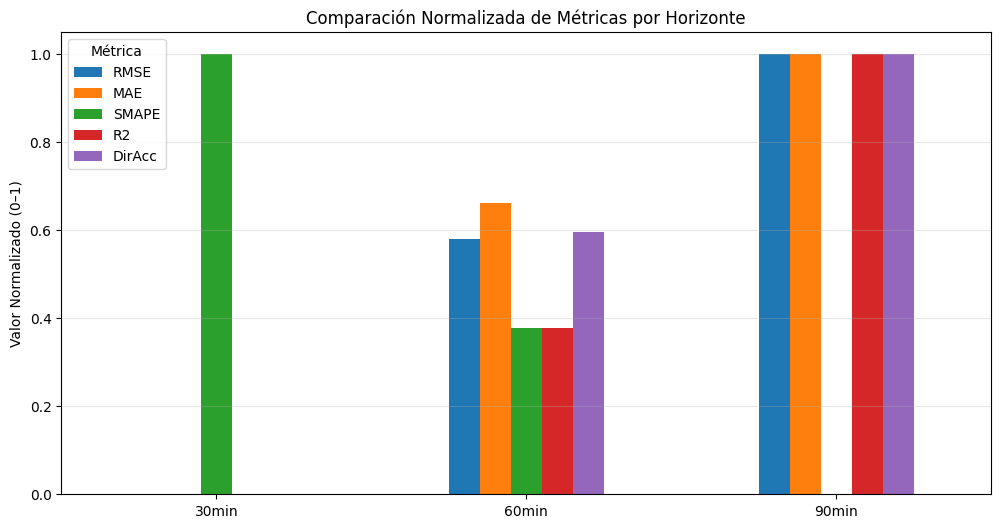

In [128]:
# Normalización min–max por fila
df_norm = df.apply(lambda row: (row - row.min()) / (row.max() - row.min()), axis=1)

# Gráfica normalizada
plt.figure(figsize=(12, 6))
df_norm.T.plot(kind="bar", figsize=(12,6))

plt.title("Comparación Normalizada de Métricas por Horizonte")
plt.ylabel("Valor Normalizado (0–1)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Métrica")
plt.show()

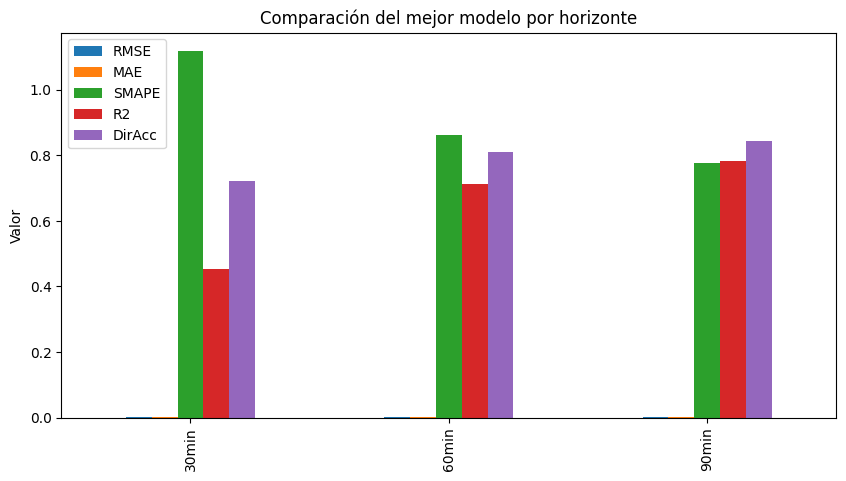

In [125]:
comparison_scaled.T.plot(kind="bar", figsize=(10,5), title="Comparación del mejor modelo por horizonte")
plt.ylabel("Valor")
plt.show()